<a href="https://colab.research.google.com/github/uu-sml/wasp-assigninmen-af-classification/blob/main/assignment_ecg_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import os

# helper function
def exists(path):
    val = os.path.exists(path)
    if val:
        print(f'{path} already exits. Using cached. Delete it manually to recieve it again!')
    return val

# Force clone requirements.txt to ensure it's fresh and present
if exists('requirements.txt'):
    !rm requirements.txt
!git clone https://gist.github.com/dgedon/8a7b91714568dc35d0527233e9ceada4.git req
!mv req/requirements.txt .
!yes | rm -r req

# Read requirements.txt and remove all version constraints
with open('requirements.txt', 'r') as f:
    lines = f.readlines()

new_lines = []
for line in lines:
    # Remove '==' and everything after it
    if '==' in line:
        package_name = line.split('==')[0]
        new_lines.append(package_name + '\n')
    else:
        new_lines.append(line)

# Write back to requirements.txt
with open('requirements.txt', 'w') as f:
    f.writelines(new_lines)

print("Modified requirements.txt: removed all version constraints.")

requirements.txt already exits. Using cached. Delete it manually to recieve it again!


'rm' is not recognized as an internal or external command,
operable program or batch file.
fatal: destination path 'req' already exists and is not an empty directory.
fatal: destination path 'req' already exists and is not an empty directory.
'mv' is not recognized as an internal or external command,
operable program or batch file.
'mv' is not recognized as an internal or external command,
operable program or batch file.


Modified requirements.txt: removed all version constraints.


'yes' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
# Install packages (python>=3.9 is required)
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [21]:
# Import
import torch
import torch.nn as nn
import numpy as np
from tqdm.notebook import trange, tqdm
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import ast
%matplotlib inline

---
## The data set

The dataset is a subset of the [*CODE dataset*](https://scilifelab.figshare.com/articles/dataset/CODE_dataset/15169716): an anotated database of ECGs. The ECG exams were recorded in Brazil by the Telehealth Network of the state Minas Gerais between 2010 and 2016. The dataset and its usage for the development of deep learning methods was described in ["Automatic diagnosis of the 12-lead ECG using a deep neural network"](https://www.nature.com/articles/s41467-020-15432-4).
The full dataset is available for research upon request.


For the training dataset you have labels.
For the test dataset you only have the ECG exams but no labels. Evaluation is done by submitting to the leaderboard.

Download the dataset from the given dropbox link and unzip the folder containing the files. The downloaded files are in WFDB format (see [here](https://www.physionet.org/content/wfdb-python/3.4.1/) for details).

In [ ]:
# import urllib.request
# DATA_URL = "https://www.dropbox.com/s/9zkqa5y5jqakdil/codesubset.tar.gz?dl=1"
# # 1. Download dataset
# if not exists('codesubset.tar.gz'):
#     print("Downloading dataset archive...")
#     urllib.request.urlretrieve(DATA_URL, "codesubset.tar.gz")
#     print("Download complete.")

KeyboardInterrupt: 

In [ ]:

'''
import tarfile
# 1. unzip the downloaded data set folder

archive_path = "codesubset.tar.gz"
extract_to = "."
if not exists('codesubset'):
    if not os.path.exists('codesubset.tar.gz'):
        raise FileNotFoundError("codesubset.tar.gz not found. Run the download cell first.")
    print("Extracting archive...")
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(path=extract_to)
    print("Extraction finished.")
'''

Extracting archive...


C:\Users\ferna\AppData\Local\Temp\ipykernel_32184\4293027510.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_to)


Extraction finished.


Note that the extraced folder 'codesubset' contains
1. subfolders with the ECG exam traces. These have to be further preprocessed which we do in the next steps.
2. a csv file which contain the labels and other features for the training data set.


### Preprocessing

Run the cells below to  Clone the GitHub repository which we use for [data preprocessing](https://github.com/antonior92/ecg-preprocessing).

In [ ]:
'''
# 2. clone the code files for data preprocessing
if not exists('ecg-preprocessing'):
    !git clone https://github.com/paulhausner/ecg-preprocessing.git
'''

ecg-preprocessing already exits. Using cached. Delete it manually to recieve it again!


Let us plot an ECG sample. We can plot ECGs using the `ecg_plot` library for example by using the following code snippet where `ecg_sample` is an array of size `(number of leads * sequence length)`. Now we can view an ECG before preprocessing.

In [ ]:
'''
import ecg_plot
import sys
sys.path.append('ecg-preprocessing')
from read_ecg import read_ecg

PATH_TO_WFDB = 'codesubset/train/TNMG100046'
ecg_sample, sample_rate, _ = read_ecg(PATH_TO_WFDB)
print(sample_rate)

# ECG plot
plt.figure()
lead = ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ecg_plot.plot(ecg_sample, sample_rate=sample_rate, style='bw', row_height=8, lead_index=lead, columns=1, title='Sample ECG before pre-processing')
plt.show()
'''

FileNotFoundError: [Errno 2] No such file or directory: 'c:/Users/ferna/Documentos/UPPSALA/PROJECT/ECG-Image_and_Model/python-example-2025/Notepad/codesubset/train/TNMG100046.hea'


The preprocessing consist of:
- resampling all ECG traces to the sample sampling period (400 Hz). Option: ``--new_freq 400``
- zero padding if necessary such that all ECG have the same number of samples (4096). Option: ``--new_len 4096``.
- removing trends in the ECG signal. Option: ``--remove_baseline``
- remove possible power line noise. Option: ``--powerline 60``

You can run the script bellow to plot the same ECG after the preprocessing.  The script also use the  `ecg_plot` library (as you did above).  You can try also with different command line options to see how the preprocessing affects the signal that will be used by the model.


Next we perform the preprocessing in all exams and convert them into one single h5 file (see [here](https://www.h5py.org/#:~:text=The%20h5py%20package%20is%20a,they%20were%20real%20NumPy%20arrays.) for details about the format). The resulting h5 files contains the traces as arrays with the shape `(number of traces * sequence length * number of leads)` where sequence length is 4096 and number of leads is 8.
The files `train.h5` and `test.h5` will be saved inside the folder `codesubset/`.

In [8]:
import h5py
f = h5py.File('signal_test_s.h5', 'r')
tracings=f['labels']
print(tracings.shape)
f.close()

(100, 5)


In [22]:
set_data = 'S' # L = large, S = small
classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

if set_data == 'S':
    h5_names = ['signal_test_s.h5', 'signal_train_s.h5']
    txt_names = ['Test_RECORDS_LowRes_s.txt', 'Train_RECORDS_LowRes_s.txt']
else:
    h5_names = ['signal_test_l.h5', 'signal_train_l.h5']
    txt_names = ['Test_RECORDS_LowRes_l.txt', 'Train_RECORDS_LowRes_l.txt']




path = r'..\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\'
sampling_rate=100

txt_file = path + "RECORDS_LowRes.txt"
with open(txt_file, "r", encoding="utf-8") as f:
    lines = [line.rstrip("\n") for line in f]

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
#X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
#X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
#X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

y_test = y_test.iloc[0:].to_list()
y_train = y_train.iloc[0:].to_list()

for i in range(len(y_test)):
    lst = np.zeros(len(classes))
    z = 0
    for j in classes:
        if j in y_test[i]:
            lst[z] = 1
        z+=1
    y_test[i] = lst

for i in range(len(y_train)):
    lst = np.zeros(len(classes))
    z = 0
    for j in classes:
        if j in y_train[i]:
            lst[z] = 1
        z+=1
    y_train[i] = lst

y_test = np.stack(y_test)
y_train = np.stack(y_train)

print(y_train.shape)

# y_test = y_test[:arrays_test.shape[0]]
# y_train = y_train[:arrays_train.shape[0]]


data_size = 0
if set_data == 'S':
    data_size = 1000
    print('Using small dataset...')
elif set_data == 'L':
    data_size = len(lines)
    print('Using large dataset...')
else:
    print('Error: No dataset specified')
    raise SystemExit  # Stops execution

ratio = len(y_test)/len(lines)
print(f'Division of test data vs train data: {ratio}')
data_size_test = int(ratio*data_size)
data_size_train = data_size - data_size_test



lines_test = []
lines_train = []
for i in range(len(lines)):
    if Y.strat_fold.iloc[i] == test_fold:
        lines_test.append(lines[i])
    else:
        lines_train.append(lines[i])

y_test = y_test[:data_size_test]
y_train = y_train[:data_size_train]

lines_test = lines_test[:data_size_test]
lines_train = lines_train[:data_size_train]




if not exists(path + txt_names[0]):

    with open(path + txt_names[0], "w", encoding="utf-8") as f:
        f.write("\n".join(lines_test))
        
if not exists(path + txt_names[1]):

    with open(path + txt_names[1], "w", encoding="utf-8") as f:
        f.write("\n".join(lines_train))





# Generate test
if not exists(h5_names[0]):
    
    !python ecg-preprocessing-main/generate_h5.py  --new_freq 400 --new_len 4096 --remove_baseline  --use_all_leads {path + txt_names[0]} {h5_names[0]}
    

with h5py.File(h5_names[0], "r+") as h5f:   # r+ = read/write without truncation
    if "labels" not in h5f:
        h5f.create_dataset("labels", data=y_test, compression="gzip")

#  Generate train
if not exists(h5_names[1]):
    !python ecg-preprocessing-main/generate_h5.py --new_freq 400 --new_len 4096 --remove_baseline  --use_all_leads {path + txt_names[1]} {h5_names[1]}

with h5py.File(h5_names[1], "r+") as h5f:   # r+ = read/write without truncation
    if "labels" not in h5f:
        h5f.create_dataset("labels", data=y_train, compression="gzip")




FileNotFoundError: [Errno 2] No such file or directory: '..\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\\\RECORDS_LowRes.txt'

### Coding Task 1: Data Analysis

Before starting to model you have to analyse the dataset. You can be creative in your way of *getting a feeling* for the data. What you have to do is:
- plot an ECG after proprocessing saved in the hdf5 file. For this use the `ecg_plot()` example above and see below for how to access the preprocessed data in h5 format.

Some further ideas to explore are:
- check the balance of the data set,
- evaluate the distribution of age and sex of the patients,
- think about the performance that a best naive classifier would achieve, e.g. by random guessing or always predicting one class.

<br />

**How to access the data?**

You can acces the data in the h5 file in the following way
```
import h5py

PATH_TO_H5_FILE = 'codesubset/train.h5'
f = h5py.File(PATH_TO_H5_FILE, 'r')
data = f['tracings']
```
Then, `data[i]` is an numpy array of the $i$th ECG exam (including all time points and leads).


[ 0.54286768  0.29554731 -0.24732037 -0.41920749  0.39509402  0.02411347
 -0.50746974 -0.65177511 -0.00500569  0.26017741  0.4278744   0.41745542]


<Figure size 1500x600 with 0 Axes>

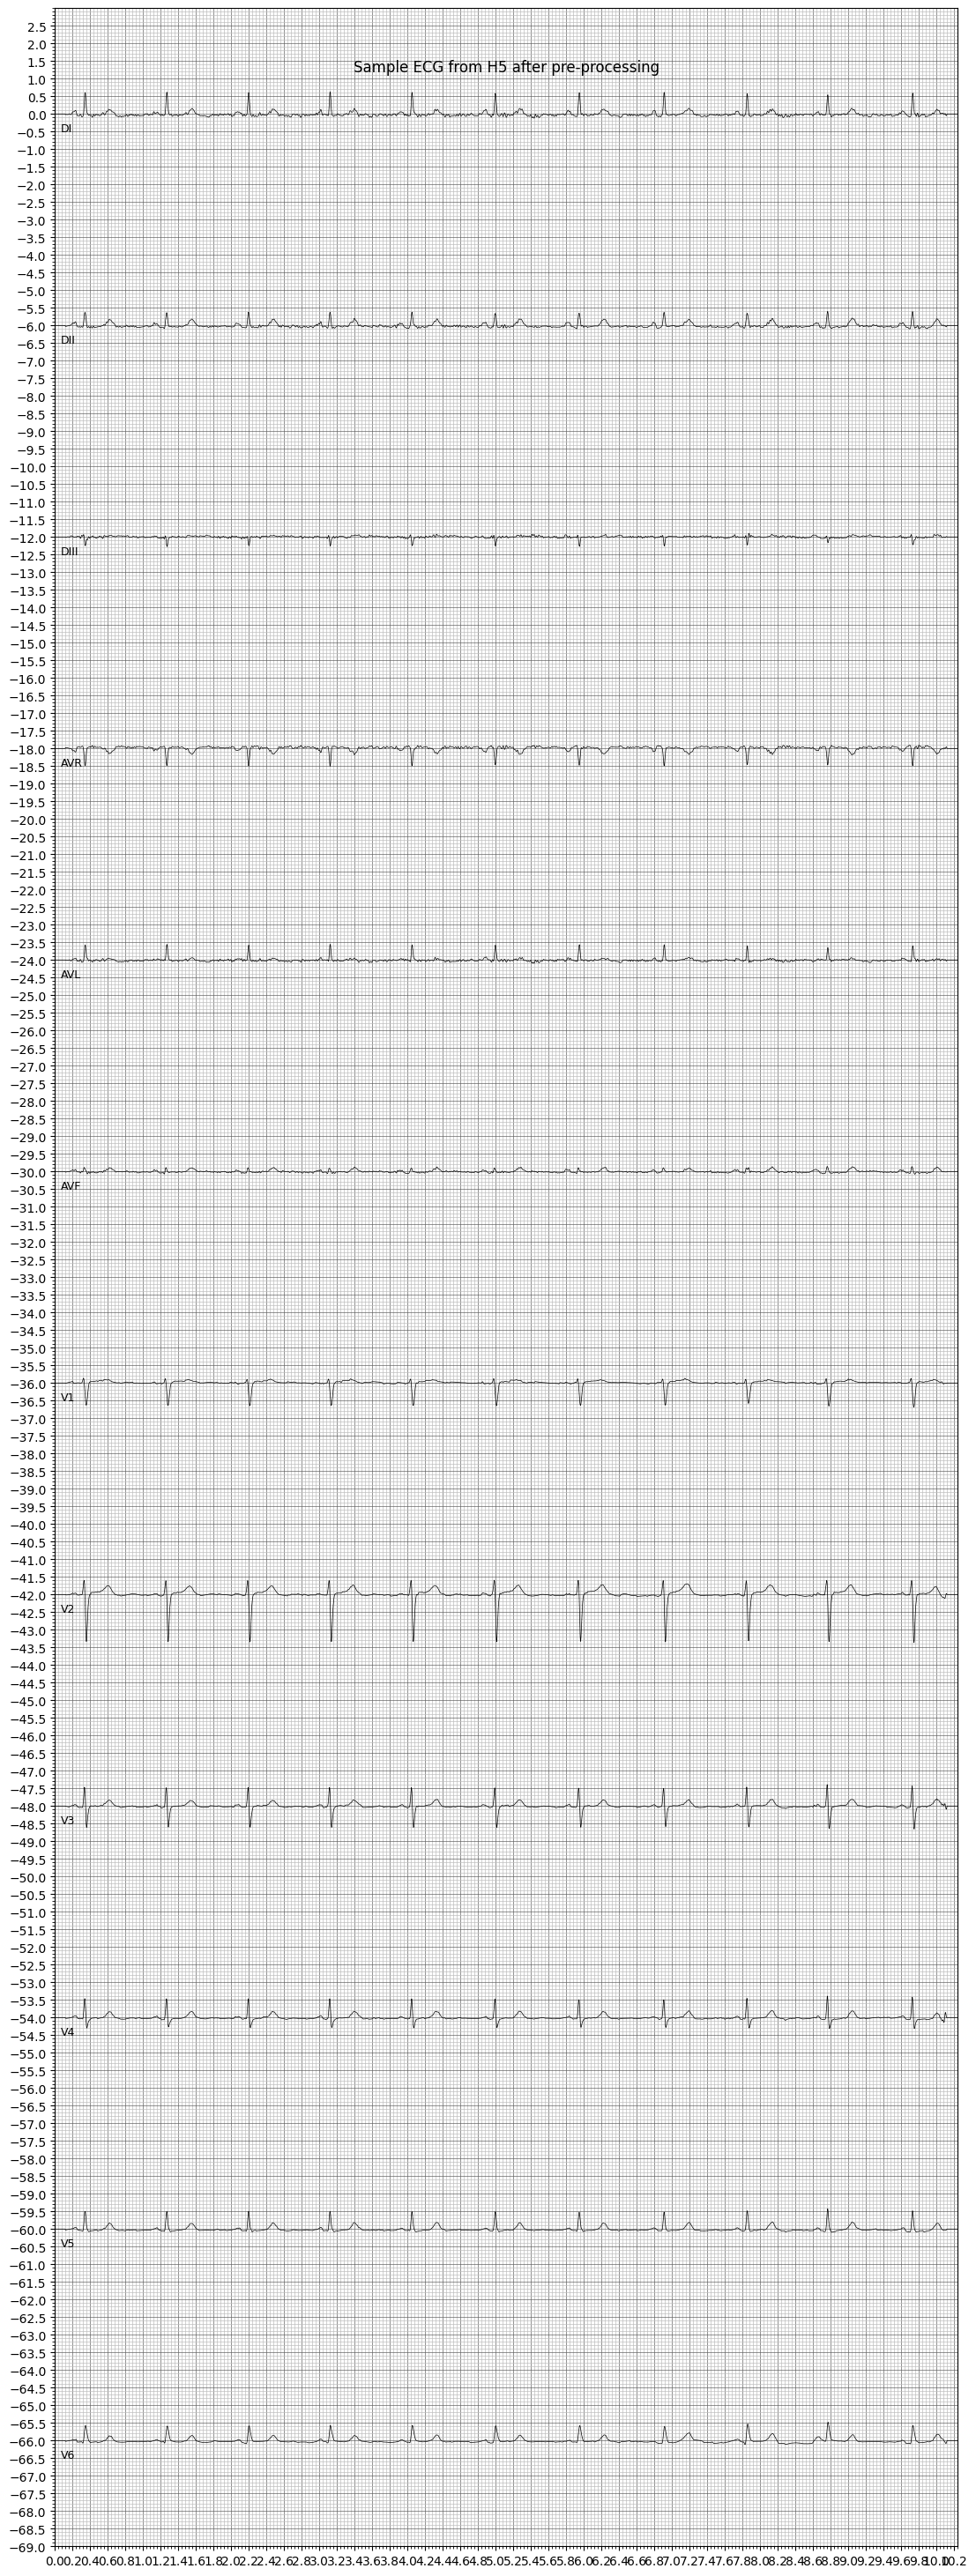

In [6]:
import h5py
import ecg_plot
import sys

PATH_TO_H5_FILE = path = 'signal_train_s.h5'
f = h5py.File(PATH_TO_H5_FILE, 'r')
data = f['tracings']
print(data[0, 2000, :12])

# Plot the first ECG sample after preprocessing
lead = ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

lead = ['I', 'II', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
reduced_leads = ['DI', 'DII', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
all_leads = ['DI', 'DII', 'DIII', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

sample_rate = 400

plt.figure(figsize=(15, 6))
ecg_plot.plot(data[0].T, sample_rate=sample_rate, style='bw', row_height=12, lead_index=all_leads, columns=1, title='Sample ECG from H5 after pre-processing')
plt.show()




In [ ]:

'''
import pandas as pd

# Path to the training CSV file
path_to_csv_train = 'codesubset/train.csv'

# Load the CSV file into a DataFrame
df_train_labels = pd.read_csv(path_to_csv_train)

print("\nDistribution of AF (Atrial Fibrillation) labels:")
display(df_train_labels['AF'].value_counts())

print("\nDistribution of Sex:")
display(df_train_labels['sex'].value_counts())

print("\nDistribution of Age:")
display(df_train_labels['age'].describe())
'''

FileNotFoundError: [Errno 2] No such file or directory: 'codesubset/train.csv'

### Explanation task 1: Data Analysis

Please explain your main findings of the data analysis task in a few bullet points. Explain also what the preprocessing does and why it is necessary.

<br />

In the training data, the distribution of positive and negative AF patients is 7000 positive, and 3000 negative. The distribution of sex is 3693 males and 6307. The mean age is 58 years.

If predictions is always AF=0, the algorithm is 70% correct.

---
## Model

The model class consists of two methods:
- `__init__(self, args)`: This methods initializes the class, e.g. by using `mymodel=ModelBaseline(args)`.
- `forward(self,input_data)`: This method is called when we run `model_output=mymodel(input_data)`.

The dimension of the input data is  `(batch size * sequence length * number of leads)`. Where **batch size** is a hyperparameter, **sequence length** is the number of ECG time samples (=4096) and **number of leads** (=8).

The `ModelBaseline` (provided below) is a 2 layer model with one convolutional layers and one linear layer. Some explanations:
- The conv layer downsamples the input traces from 4096 samples to 128 samples and increases the number of channels from 8 (=number of leads) to 32. Here we use a kernel size of 3.
- The linear layer uses the flattened output from the conv and outputs one prediction. Since we have a binary problem, a single prediction is sufficient.


In [7]:
class ModelBaseline(nn.Module):
    def __init__(self,):
        super(ModelBaseline, self).__init__()
        self.kernel_size = 3

        # conv layer
        downsample = self._downsample(4096, 128)
        self.conv1 = nn.Conv1d(in_channels=8,
                               out_channels=32,
                               kernel_size=self.kernel_size,
                               stride=downsample,
                               padding=self._padding(downsample),
                               bias=False)

        # linear layer
        self.lin = nn.Linear(in_features=32*128,
                             out_features=1)

        # ReLU
        self.relu = nn.ReLU()

    def _padding(self, downsample):
        return max(0, int(np.floor((self.kernel_size - downsample + 1) / 2)))

    def _downsample(self, seq_len_in, seq_len_out):
        return int(seq_len_in // seq_len_out)


    def forward(self, x):
        x= x.transpose(2,1)

        x = self.relu(self.conv1(x))
        x_flat= x.view(x.size(0), -1)
        x = self.lin(x_flat)

        return x

#---------------------------------------------------------------



def _padding(downsample, kernel_size):
    """Compute required padding"""
    padding = max(0, int(np.floor((kernel_size - downsample + 1) / 2)))
    return padding


def _downsample(n_samples_in, n_samples_out):
    """Compute downsample rate"""
    downsample = int(n_samples_in // n_samples_out)
    if downsample < 1:
        raise ValueError("Number of samples should always decrease")
    if n_samples_in % n_samples_out != 0:
        raise ValueError("Number of samples for two consecutive blocks "
                         "should always decrease by an integer factor.")
    return downsample


class ResBlock1d(nn.Module):
    """Residual network unit for unidimensional signals."""

    def __init__(self, n_filters_in, n_filters_out, downsample, kernel_size, dropout_rate):
        if kernel_size % 2 == 0:
            raise ValueError("The current implementation only support odd values for `kernel_size`.")
        super(ResBlock1d, self).__init__()
        # Forward path
        padding = _padding(1, kernel_size)
        self.conv1 = nn.Conv1d(n_filters_in, n_filters_out, kernel_size, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm1d(n_filters_out)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        padding = _padding(downsample, kernel_size)
        self.conv2 = nn.Conv1d(n_filters_out, n_filters_out, kernel_size,
                               stride=downsample, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(n_filters_out)
        self.dropout2 = nn.Dropout(dropout_rate)

        # Skip connection
        skip_connection_layers = []
        # Deal with downsampling
        if downsample > 1:
            maxpool = nn.MaxPool1d(downsample, stride=downsample)
            skip_connection_layers += [maxpool]
        # Deal with n_filters dimension increase
        if n_filters_in != n_filters_out:
            conv1x1 = nn.Conv1d(n_filters_in, n_filters_out, 1, bias=False)
            skip_connection_layers += [conv1x1]
        # Build skip conection layer
        if skip_connection_layers:
            self.skip_connection = nn.Sequential(*skip_connection_layers)
        else:
            self.skip_connection = None

    def forward(self, x, y):
        """Residual unit."""
        if self.skip_connection is not None:
            y = self.skip_connection(y)
        else:
            y = y
        # 1st layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)

        # 2nd layer
        x = self.conv2(x)
        x += y  # Sum skip connection and main connection
        y = x
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        return x, y


class ResNet1d(nn.Module):
    """Residual network for unidimensional signals.
    Parameters
    ----------
    input_dim : tuple
        Input dimensions. Tuple containing dimensions for the neural network
        input tensor. Should be like: ``(n_filters, n_samples)``.
    blocks_dim : list of tuples
        Dimensions of residual blocks.  The i-th tuple should contain the dimensions
        of the output (i-1)-th residual block and the input to the i-th residual
        block. Each tuple shoud be like: ``(n_filters, n_samples)``. `n_samples`
        for two consecutive samples should always decrease by an integer factor.
    dropout_rate: float [0, 1), optional
        Dropout rate used in all Dropout layers. Default is 0.8
    kernel_size: int, optional
        Kernel size for convolutional layers. The current implementation
        only supports odd kernel sizes. Default is 17.
    References
    ----------
    .. [1] K. He, X. Zhang, S. Ren, and J. Sun, "Identity Mappings in Deep Residual Networks,"
           arXiv:1603.05027, Mar. 2016. https://arxiv.org/pdf/1603.05027.pdf.
    .. [2] K. He, X. Zhang, S. Ren, and J. Sun, "Deep Residual Learning for Image Recognition," in 2016 IEEE Conference
           on Computer Vision and Pattern Recognition (CVPR), 2016, pp. 770-778. https://arxiv.org/pdf/1512.03385.pdf
    """

    def __init__(self, input_dim, blocks_dim, n_classes, kernel_size=17, dropout_rate=0.8):
        super(ResNet1d, self).__init__()
        # First layers
        n_filters_in, n_filters_out = input_dim[0], blocks_dim[0][0]
        n_samples_in, n_samples_out = input_dim[1], blocks_dim[0][1]
        downsample = _downsample(n_samples_in, n_samples_out)
        padding = _padding(downsample, kernel_size)
        self.conv1 = nn.Conv1d(n_filters_in, n_filters_out, kernel_size, bias=False,
                               stride=downsample, padding=padding)
        self.bn1 = nn.BatchNorm1d(n_filters_out)

        # Residual block layers
        self.res_blocks = []
        for i, (n_filters, n_samples) in enumerate(blocks_dim):
            n_filters_in, n_filters_out = n_filters_out, n_filters
            n_samples_in, n_samples_out = n_samples_out, n_samples
            downsample = _downsample(n_samples_in, n_samples_out)
            resblk1d = ResBlock1d(n_filters_in, n_filters_out, downsample, kernel_size, dropout_rate)
            self.add_module('resblock1d_{0}'.format(i), resblk1d)
            self.res_blocks += [resblk1d]

        # Linear layer
        n_filters_last, n_samples_last = blocks_dim[-1]
        last_layer_dim = n_filters_last * n_samples_last
        self.lin = nn.Linear(last_layer_dim, n_classes)
        self.n_blk = len(blocks_dim)

    def forward(self, x):
        """Implement ResNet1d forward propagation"""

        x= x.transpose(2,1) #Added to the model from baseline to avoid dimension error 


        # First layers
        x = self.conv1(x)
        x = self.bn1(x)

        # Residual blocks
        y = x
        for blk in self.res_blocks:
            x, y = blk(x, y)

        # Flatten array
        x = x.view(x.size(0), -1)

        # Fully conected layer
        x = self.lin(x)
        return x



### Coding Task 2: Define your model

In the cell below you have to define your model. You can be inspired by the baseline model above but you can also define any other kind of neural network architecture.

In [8]:
class Model(nn.Module):
    def __init__(self,):
        super(Model, self).__init__()
        self.kernel_size = 3

        # conv layer 1
        downsample1 = self._downsample(4096, 128)
        self.conv1 = nn.Conv1d(in_channels=8,
                               out_channels=64,
                               kernel_size=self.kernel_size,
                               stride=downsample1,
                               padding=self._padding(downsample1),
                               bias=False)
        self.bn1 = nn.BatchNorm1d(64)

        # conv layer 2
        downsample2 = self._downsample(128, 64)
        self.conv2 = nn.Conv1d(in_channels=64,
                               out_channels=128,
                               kernel_size=self.kernel_size,
                               stride=downsample2,
                               padding=self._padding(downsample2),
                               bias=False)
        self.bn2 = nn.BatchNorm1d(128)

        # conv layer 3
        downsample3 = self._downsample(64, 32)
        self.conv3 = nn.Conv1d(in_channels=128,
                               out_channels=256,
                               kernel_size=self.kernel_size,
                               stride=downsample3,
                               padding=self._padding(downsample3),
                               bias=False)
        self.bn3 = nn.BatchNorm1d(256)

        # conv layer 4
        downsample4 = self._downsample(32, 16)
        self.conv4 = nn.Conv1d(in_channels=256,
                               out_channels=512,
                               kernel_size=self.kernel_size,
                               stride=downsample4,
                               padding=self._padding(downsample4),
                               bias=False)
        self.bn4 = nn.BatchNorm1d(512)

        # conv layer 5
        downsample5 = self._downsample(16, 8)
        self.conv5 = nn.Conv1d(in_channels=512,
                               out_channels=1024,
                               kernel_size=self.kernel_size,
                               stride=downsample5,
                               padding=self._padding(downsample5),
                               bias=False)
        self.bn5 = nn.BatchNorm1d(1024)

        # linear layer 1
        self.lin1 = nn.Linear(in_features=1024*8,
                             out_features=512*8)

        # linear layer 2
        self.lin2 = nn.Linear(in_features=512*8,
                             out_features=1)

        # ReLU
        self.relu = nn.ReLU()

        # Dropout
        self.drop = nn.Dropout(p=0.2)

    def _padding(self, downsample):
        return max(0, int(np.floor((self.kernel_size - downsample + 1) / 2)))

    def _downsample(self, seq_len_in, seq_len_out):
        return int(seq_len_in // seq_len_out)


    def forward(self, x):
        x = x.transpose(2,1)

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.relu(self.bn5(self.conv5(x)))

        x_flat = x.view(x.size(0), -1)
        x = self.lin1(x_flat)
        x = self.relu(x)
        x = self.drop(x)
        x = self.lin2(x)

        return x

### Explanation Task 2: Final Model
Please explain and motivate in short sentences or bullet points the choice of your final model.

<br />


**<font color='red'>Your explanation here:</font>**

We added another convolutional layer to try and speed up the algorithm even further than the baseline model.

---
## Train function

The function `train(...)` is called to in every epoch to train the model. The function loads the training data, makes predictions, compares predictions with true labels in the loss function and adapting the model parameters using stochastic gradient descent.

In the code cell below there is the basic structure to load data from the data loader and to log your loss. The arguments of the function are explained by the use in the `main(...)` function below.

If you are unfamiliar with PyTorch training loops, then this official [tutorial](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) might help (especially section "4. Train your Network").

### Coding Task 3: Fill training loop

Fill the code cell below such that the model is training when `train(...)` is called.

In [9]:
def train_loop(epoch, dataloader, model, optimizer, loss_function, device):
    # model to training mode (important to correctly handle dropout or batchnorm layers)
    model.train()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    # progress bar def
    train_pbar = tqdm(dataloader, desc="Training Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # training loop
    for traces, labels in train_pbar:
        # data to device (CPU or GPU if available)
        traces, labels = traces.to(device), labels.to(device)

        """
        TASK: Insert your code here. This task can be done in 5 lines of code.
        """
        optimizer.zero_grad()
        outputs = model(traces)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(traces)

        # Update progress bar
        train_pbar.set_postfix({'loss': total_loss / n_entries})
    train_pbar.close()
    return total_loss / n_entries

---
## Eval function

The `eval(...)` function is similar to the `train(...)` function but is used to evaluate the model on validation data without adapting the model parameters. You can prohibit computing gradients by using a `with torch.no_grad():` statement.

Currenlty only the loss is logged here. Additionally you have to collect all your predictions and the true values in order to compute more metrics such as AUROC.

### Coding Task 4: Fill evaluation loop
Fill the code cell below such we obtain model predictions to evaluate the validation loss and collect the prediction in order to compute other validation metrics in the `main(...)` function.

In [10]:
def eval_loop(epoch, dataloader, model, loss_function, device):
    # model to evaluation mode (important to correctly handle dropout or batchnorm layers)
    model.eval()
    # allocation
    total_loss = 0  # accumulated loss
    n_entries = 0   # accumulated number of data points
    valid_probs = []  # accumulated predicted probabilities
    valid_true = [] # accumulated true labels

    # progress bar def
    eval_pbar = tqdm(dataloader, desc="Evaluation Epoch {epoch:2d}".format(epoch=epoch), leave=True)
    # evaluation loop
    for traces_cpu, labels_cpu in eval_pbar:
        # data to device (CPU or GPU if available)
        traces, labels = traces_cpu.to(device), labels_cpu.to(device)

        """
        TASK: Insert your code here. This task can be done in 6 lines of code.
        """

        with torch.no_grad():
            outputs = model(traces)
            loss = loss_function(outputs, labels)
            probabilities = torch.sigmoid(outputs)

        valid_probs.append(probabilities.cpu().numpy())
        valid_true.append(labels.cpu().numpy())

        # Update accumulated values
        total_loss += loss.detach().cpu().numpy()
        n_entries += len(traces)

        # Update progress bar
        eval_pbar.set_postfix({'loss': total_loss / n_entries})
    eval_pbar.close()
    return total_loss / n_entries, np.vstack(valid_probs), np.vstack(valid_true)

---
## Run Training

In the code cell below there are some initial (non-optimal!) training hyperparameters. Further, we combine everything from above into training code. That means that we build the dataloaders, define the model/loss/optimizer and then train/validate the model over multiple epochs. Here, we save the model with the lowest validation loss as the best model.

### Coding Task 5: Combine everything to train/validate the model

The following tasks are necessary in the code below
- split the data into training and validation data
- define the loss function
- decide and implement validation metric(s) to evaluate and compare the model on

Optional task:
- include learning rate scheduler
- take specific care about possible data inbalance

### Coding Task 6: Run your model and adapt hyperparameters

After you combined everything in task 5, now you run the code to evaluate the model. Based on the resulting validation metrics you tune
- the training hyperparameters
- the model architecture
- the model hyperparameters.

### Explanation Task 3: Hyperparameter
Please explain and motivate in short sentences or bullet points the final choice of hyperparamer and how you developed them.

<br />


**<font color='red'>Your explanation here:</font>**


In [12]:
# set seed
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# choose variables
"""
TASK: Adapt the following hyperparameters. Using defaults from Signal based code
"""
learning_rate = 1e-3
weight_decay = 1e-4
num_epochs = 15
batch_size = 32

In [13]:
from torch.utils.data import TensorDataset, random_split, DataLoader

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tqdm.write("Use device: {device:}\n".format(device=device))

# =============== Build data loaders ======================================#
tqdm.write("Building data loaders...")

# path_to_h5_train, path_to_csv_train, path_to_records = 'codesubset/train.h5', 'codesubset/train.csv', 'codesubset/train/RECORDS.txt'
# # load traces
# traces = torch.tensor(h5py.File(path_to_h5_train, 'r')['tracings'][()], dtype=torch.float32)
# # load labels
# ids_traces = [int(x.split('TNMG')[1]) for x in list(pd.read_csv(path_to_records, header=None)[0])] # Get order of ids in traces
# df = pd.read_csv(path_to_csv_train)
# df.set_index('id_exam', inplace=True)
# df = df.reindex(ids_traces) # make sure the order is the same
# labels = torch.tensor(np.array(df['AF']), dtype=torch.float32).reshape(-1,1)

if set_data == 'S':
    path_to_h5_train = 'signal_train_s.h5'
else:
    path_to_h5_train = 'signal_train_l.h5'



traces = torch.tensor(h5py.File(path_to_h5_train, 'r')['tracings'][()], dtype=torch.float32)
labels = torch.tensor(h5py.File(path_to_h5_train, 'r')['labels'][()], dtype=torch.float32) 




# load dataset
dataset = TensorDataset(traces, labels)
len_dataset = len(dataset)
n_classes = len(torch.unique(labels))
# split data
"""
TASK: Split the dataset in train and validation; Insert your code here.
This can be done in <=4 line of code
"""
train_size = int(0.8 * len_dataset)
valid_size = len_dataset - train_size
dataset_train, dataset_valid = random_split(dataset, [train_size, valid_size])


# build data loaders
train_dataloader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)
tqdm.write("Done!\n")

Use device: cpu

Building data loaders...
Done!

Done!



In [15]:
# =============== Define model ============================================#
tqdm.write("Define model...")
"""
TASK: Replace the baseline model with your model; Insert your code here
"""

# Model parameters (Using defaults from program) ----------
seq_length, N_LEADS = traces.shape[1:] # seq_length: sample dim 4096 , N_LEADS:the 12 leads
kernel_size=17
dropout_rate = 0.8
net_filter_size= [64, 128, 196, 256, 320]
net_seq_lengh=[4096, 1024, 256, 64, 16]

#-----------------------------------------------------
N_CLASSES = len(classes)  # 5 diagnosis
model = ResNet1d(input_dim=(N_LEADS, seq_length),
                    blocks_dim=list(zip(net_filter_size, net_seq_lengh)),
                    n_classes=N_CLASSES,
                    kernel_size=kernel_size,
                    dropout_rate=dropout_rate)
model.to(device=device)
tqdm.write("Done!\n")



# =============== Define loss function ====================================#
"""
TASK: define the loss; Insert your code here. This can be done in 1 line of code
"""
# Define weights because imbalance
class_counts = np.array([9514, 5469, 5235, 4898, 2649])
N = np.sum(class_counts)

weights = N / class_counts
weights = weights / np.max(weights) # Normalize
weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Class weights: {weights}')

#weights2 = torch.tensor([1.291, 2.986, 3.164, 3.451, 7.229], dtype=torch.float32).to(device)
weights2 = (N-class_counts) / class_counts
weights2 = weights2 / np.max(weights2) # Normalize
weights2 = torch.tensor(weights2, dtype=torch.float32).to(device)
print(f'Class weights2: {weights2}')

tqdm.write("Define loss function...")
#loss_function = nn.CrossEntropyLoss()
loss_function = nn.BCEWithLogitsLoss() #pos_weight=weights2
#loss_function = nn.BCELoss()
tqdm.write("Done!\n")

# =============== Define optimizer ========================================#
tqdm.write("Define optimiser...")
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
tqdm.write("Done!\n")

# =============== Define lr scheduler =====================================#
# TODO advanced students (non mandatory)
"""
OPTIONAL: define a learning rate scheduler; Insert your code here
"""
lr_scheduler = None

# =============== Train model =============================================#
tqdm.write("Training...")
best_loss = np.inf
# allocation
train_loss_all, valid_loss_all = [], []

score_list = []
# loop over epochs
for epoch in trange(1, num_epochs + 1):
    # training loop
    train_loss = train_loop(epoch, train_dataloader, model, optimizer, loss_function, device)
    # validation loop
    valid_loss, y_pred, y_true = eval_loop(epoch, valid_dataloader, model, loss_function, device)

    # collect losses
    train_loss_all.append(train_loss)
    valid_loss_all.append(valid_loss)

    # compute validation metrics for performance evaluation
    """
    TASK: compute validation metrics (e.g. AUROC); Insert your code here
    This can be done e.g. in 5 lines of code
    """
    from sklearn.metrics import roc_auc_score
    auroc = roc_auc_score(y_true=y_true, y_score=y_pred)
    score_list.append(auroc)

    # save best model: here we save the model only for the lowest validation loss
    if valid_loss < best_loss:
        # Save model parameters
        torch.save({'model': model.state_dict()}, 'signal_model.pth')
        # Update best validation loss
        best_loss = valid_loss
        # statement
        model_save_state = "Best model -> saved"
    else:
        model_save_state = ""

    # Print message
    tqdm.write('Epoch {epoch:2d}: \t'
                'Train Loss {train_loss:.6f} \t'
                'Valid Loss {valid_loss:.6f} \t'
                '{model_save}'
                .format(epoch=epoch,
                        train_loss=train_loss,
                        valid_loss=valid_loss,
                        model_save=model_save_state)
                    )

    # Update learning rate with lr-scheduler
    if lr_scheduler:
        lr_scheduler.step()

"""
TASK: Here it can make sense to plot your learning curve; Insert your code here
"""


Define model...
Done!

Class weights: tensor([0.2784, 0.4844, 0.5060, 0.5408, 1.0000])
Class weights2: tensor([0.2023, 0.4300, 0.4539, 0.4924, 1.0000])
Define loss function...
Done!

Define optimiser...
Done!

Training...


  0%|          | 0/15 [00:00<?, ?it/s]

Training Epoch  1:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluation Epoch  1:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch  1: 	Train Loss 0.018924 	Valid Loss 0.021933 	Best model -> saved


...

Epoch 14: 	Train Loss 0.009714 	Valid Loss 0.011474 	


Training Epoch 15:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluation Epoch 15:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 15: 	Train Loss 0.010244 	Valid Loss 0.013171 	


'\nTASK: Here it can make sense to plot your learning curve; Insert your code here\n'

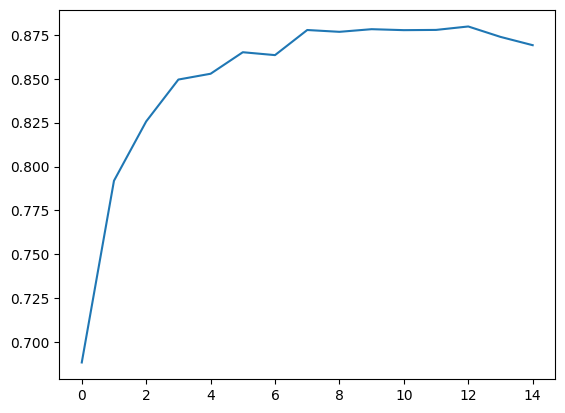

In [16]:
plt.plot(score_list)
plt.show()

---
## Model Testing

Since we saved our best model, we can now load the trained model and make predictions on the test data set. We save the predictions in a csv file which will be uploaded as part of the deliverables. Note that we take a `Sigmoid()` function on the model prediction in order to obtain soft predictions (probabilities) instead of hard predictions (0s or 1s).

### Coding Task 7: Make prediction for test data

Here you do not really need to code but you have to:
- replace the baseline model with your model. If you do not use colab then change the path to the model location to load the trained model)
- run the script. The predictions are saved in the variable `soft_pred`.
- upload your predictions to the leaderboard online (see instruction details below).

In [17]:
# build the dataloader once and re-use when running the cell below possibly multiple times.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =============== Build data loaders ==========================================#
tqdm.write("Building data loaders...")
# load data
if set_data == 'S':
    path_to_h5_test = 'signal_test_s.h5'
else:
    path_to_h5_test = 'signal:test_l.h5'
    
images_test = torch.tensor(h5py.File(path_to_h5_test, 'r')['tracings'][()], dtype=torch.float32)
labels_test = torch.tensor(h5py.File(path_to_h5_test, 'r')['labels'][()], dtype=torch.float32)
dataset_test = TensorDataset(images_test, labels_test)
len_dataset_test = len(dataset_test)

# build data loaders
test_dataloader = DataLoader(dataset_test, batch_size=32, shuffle=False)
tqdm.write("Done!\n")

Building data loaders...
Done!



In [18]:
# load stored model parameters
ckpt = torch.load('signal_model.pth', map_location=lambda storage, loc: storage)
model.load_state_dict(ckpt['model'])
# put model on device
model.to(device=device)
tqdm.write("Done!\n")

# =============== Evaluate model ==============================================#
model.eval()
# allocation
test_pred = torch.zeros(len_dataset,len(classes))
# progress bar def
test_pbar = tqdm(test_dataloader, desc="Testing")
# evaluation loop
end=0
for traces in test_pbar:
    # data to device
    traces = traces[0].to(device)
    start = end
    with torch.no_grad():
        # Forward pass
        model_output = model(traces)

        # store output
        end = min(start + len(model_output), test_pred.shape[0])
        test_pred[start:end] = torch.nn.Sigmoid()(model_output).detach().cpu()

test_pbar.close()

# =============== Save predictions ============================================#
soft_pred = np.stack((1-test_pred.numpy(), test_pred.numpy()),axis=1).squeeze()

Done!



Testing:   0%|          | 0/4 [00:00<?, ?it/s]

In [19]:
from sklearn.metrics import accuracy_score
import h5py
f = h5py.File('signal_test_s.h5', 'r')
tracings=f['labels']
print(tracings.shape)
f.close()

# y_true and y_pred are available from the last evaluation loop on the validation set

# Convert probabilities (y_pred) to binary predictions using a threshold of 0.5
#print(y_pred)
predictions = (y_pred >= 0.5).astype(int)

for i in range(10):
    print(f'{predictions[i]} = {y_true[i]} = {y_pred[i]}')

# Calculate accuracy
accuracy = accuracy_score(y_true, predictions)
auroc = roc_auc_score(y_true=y_true, y_score=predictions)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation AUROC: {auroc:.4f}")

(100, 5)
[0 0 0 1 0] = [0. 0. 0. 1. 0.] = [0.18072638 0.2351042  0.08065623 0.547523   0.00189724]
[1 0 0 0 0] = [1. 0. 0. 0. 0.] = [9.4385505e-01 9.9924859e-03 4.3941699e-03 3.6599196e-03 3.3873506e-04]
[0 0 1 0 0] = [0. 1. 0. 0. 0.] = [0.04217367 0.19602665 0.8234381  0.01369393 0.01184178]
[0 0 1 0 0] = [0. 0. 0. 1. 0.] = [7.1828364e-04 4.6601897e-01 9.2723888e-01 8.6468495e-02 3.9118350e-02]
[0 0 0 0 0] = [0. 1. 0. 0. 0.] = [0.08170046 0.35562724 0.37257573 0.05085167 0.02030305]
[0 0 0 0 0] = [1. 0. 0. 0. 0.] = [0.45519027 0.05092544 0.2303487  0.00419065 0.00082315]
[0 0 0 0 0] = [0. 0. 1. 1. 0.] = [0.14207552 0.07489893 0.3791902  0.05915653 0.03844759]
[0 0 1 0 0] = [1. 0. 0. 0. 0.] = [0.01302531 0.37258694 0.8310983  0.05695617 0.04376896]
[0 0 0 0 0] = [1. 0. 0. 0. 0.] = [0.28933457 0.18368752 0.12989788 0.08028067 0.00512383]
[1 0 0 0 0] = [1. 0. 0. 0. 0.] = [0.87117004 0.01710643 0.01413504 0.01958342 0.00226704]
Validation Accuracy: 0.4944
Validation AUROC: 0.7077


To upload your predictions to the leaderboard, use the following code. There are the following steps to follow:
1. Download the GitHub repository for the leaderboard submission system.
2. Register your team with a **team id** and **password**. The password ensures that only your team can upload to your team id. Do only run the registration once.
3. Upload you predictions as a new submission. There are some things to obey here:
    - For each submission you have to attach a note for you to keep track of the submission in the leaderboard and for us to know which submission you refer to in your explanation. Choose something meaningful such as "submission A" or "model B".
    - You can only get one prediction evaluated per day and you get the score the following day. If you do multiple submissions on the same day, the initial submission will be overwritten and thus only the final submission will be evaluated.
    - Only a maximum of ***FIVE*** submissions will be evaluated. So make them count! (If you update an submission before it is evaluated it doesn't count)
    - The evaluation score is published with you team_id and note at http://hyperion.it.uu.se:5050/leaderboard



### Explanation Task 4: Submissions
One of the grading criteria are three submissions to the leaderboard. List the three main submissions in the table below and explain the main changes in your code for each submission.

<br />


**<font color='red'>Your explanation here:</font>**

Your team id: **<font color='red'>Fill in</font>**

| Submission note | Accuracy | F1 | AUC | AP | Submission description |
| --------------- | -------- | -- | --  | -- | ---------------------- |
|xxx              | 0        | 0  | 0   | 0  | desc                   |
|xxx              | 0        | 0  | 0   | 0  | desc                   |
|xxx              | 0        | 0  | 0   | 0  | desc                   |

### Explanation Task 5: Reflection on Metrics
Your were asked to reach a certain value in AUC and AP while maximising F1 for the leaderboard position. Explain in bullet points what aspect each of the metrics covers and why it is important not to just focus on one metric. What can happen if you only focus on AUC for example?

<br />

**<font color='red'>Your explanation here:</font>**